# 📊 Sales Analysis and Data Visualization

This project analyzes a retail sales dataset to identify revenue patterns, customer behavior, regional performance, and key business insights.

---

- Kaggle - SuperStore Dataset
- Color_caio = "#5C90BD"


## 🎯 Project Objectives

- Explore and understand the dataset
- Identify top-performing categories, regions, customers, and products
- Apply the Pareto Principle (80/20 Rule)
- Create professional visualizations using Matplotlib
- Generate business insights from sales data

# 📚 1. Import Libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# 📂 2. Load Dataset

Load the sales dataset and perform an initial inspection.

In [2]:
sales_df = pd.read_csv("train.csv")
sales_df.head()

caio_blue = "#5C90BD"

# 🔎 3. Data Exploration

Explore the dataset structure, data types, and statistical information.

In [3]:
sales_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9800 non-null   int64  
 1   Order ID       9800 non-null   str    
 2   Order Date     9800 non-null   str    
 3   Ship Date      9800 non-null   str    
 4   Ship Mode      9800 non-null   str    
 5   Customer ID    9800 non-null   str    
 6   Customer Name  9800 non-null   str    
 7   Segment        9800 non-null   str    
 8   Country        9800 non-null   str    
 9   City           9800 non-null   str    
 10  State          9800 non-null   str    
 11  Postal Code    9789 non-null   float64
 12  Region         9800 non-null   str    
 13  Product ID     9800 non-null   str    
 14  Category       9800 non-null   str    
 15  Sub-Category   9800 non-null   str    
 16  Product Name   9800 non-null   str    
 17  Sales          9800 non-null   float64
dtypes: float64(2), int6

In [4]:
sales_df.describe()

,Row ID,Postal Code,Sales
count,9800.000000,9789.000000,9800.000000
mean,4900.500000,55273.322403,230.769059
std,2829.160653,32041.223413,626.651875
min,1.000000,1040.000000,0.444000
25%,2450.750000,23223.000000,17.248000
50%,4900.500000,58103.000000,54.490000
75%,7350.250000,90008.000000,210.605000
max,9800.000000,99301.000000,22638.480000


# 🧹 4. Data Quality Assessment

Check for missing values and potential data quality issues.

In [5]:
sales_df.isnull().sum()

Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
Country           0
City              0
State             0
Postal Code      11
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
dtype: int64

# 📈 5. Key Business Metrics

Calculate core business indicators.

In [6]:
total_revenue = sales_df["Sales"].sum()

print(f"Total Revenue: US$ {total_revenue:,.2f}")

Total Revenue: US$ 2,261,536.78


In [7]:
average_sale = sales_df["Sales"].mean()

print(f"Average Sale: US$ {average_sale:,.2f}")

Average Sale: US$ 230.77


In [8]:
total_orders = sales_df["Order ID"].nunique()

print(f"Total Orders: {total_orders}")

Total Orders: 4922


# 🏷️ 6. Sales by Category

Analyze revenue distribution across product categories.

In [9]:
sales_by_category = (
    sales_df.groupby("Category")["Sales"]
    .sum()
    .sort_values(ascending=False)
)

total_category_sales = sales_by_category.sum()

# 🌎 7. Sales by Region

Analyze how revenue is distributed across regions.

In [10]:
sales_by_region = (
    sales_df.groupby("Region")["Sales"]
    .sum()
    .sort_values(ascending=False)
)

total_region_sales = sales_by_region.sum()

# 👥 8. Top Customers

Identify the customers responsible for the highest revenue.

In [11]:
top_customers = (
    sales_df.groupby("Customer Name")["Sales"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

total_customers_sales = top_customers.sum()

# 📦 9. Top Products

Identify the products generating the highest revenue.

In [12]:
top_products = (
    sales_df.groupby("Product Name")["Sales"]
    .sum()
    .sort_values(ascending=False)
    .head(20)
)

# 📊 10. Pareto Analysis (80/20 Rule)

Determine whether a small group of products is responsible for most of the revenue.

In [13]:
pareto_df = (
    sales_df.groupby("Product Name")["Sales"]
    .sum()
    .sort_values(ascending=False)
    .head(20)
    .reset_index()
)

pareto_df.columns = [
    "Product",
    "Revenue"
]

In [14]:
pareto_df["Percentage"] = (
    pareto_df["Revenue"] /
    pareto_df["Revenue"].sum() * 100
)

pareto_df["Cumulative Percentage"] = (
    pareto_df["Percentage"].cumsum()
)

# 📉 11. Data Visualization

Visualize sales performance using Matplotlib charts.

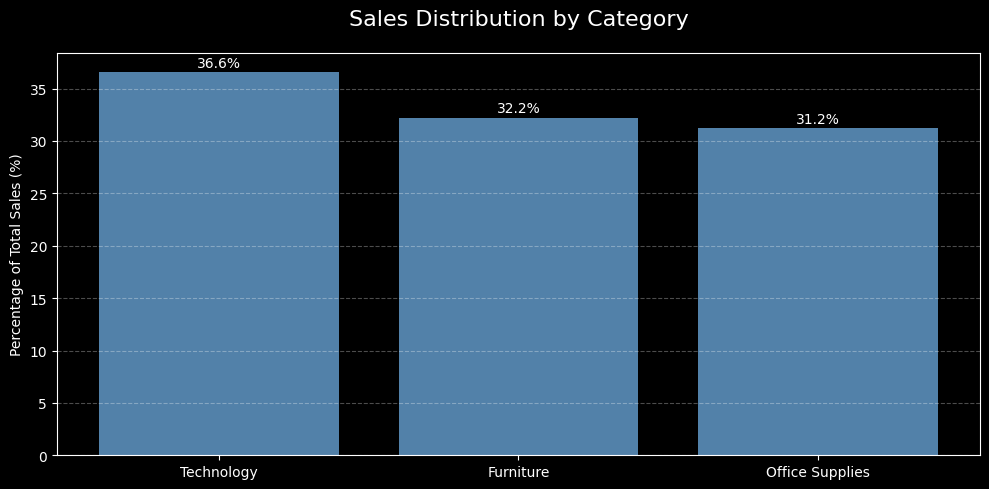

In [15]:
category_percentage = (
    sales_by_category /
    total_category_sales * 100
)

plt.style.use("dark_background")

fig, ax = plt.subplots(figsize=(10, 5))

bars = ax.bar(
    category_percentage.index,
    category_percentage,
    color=caio_blue,
    alpha=0.9
)

ax.set_title(
    "Sales Distribution by Category",
    fontsize=16,
    pad=20
)

ax.set_ylabel("Percentage of Total Sales (%)")

ax.grid(
    axis="y",
    linestyle="--",
    alpha=0.3
)

for bar in bars:
    height = bar.get_height()

    ax.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.5,
        f"{height:.1f}%",
        ha="center"
    )

plt.tight_layout()

plt.savefig(
    "images/category_revenue.png",
    bbox_inches="tight",
    dpi=300
)

plt.show()



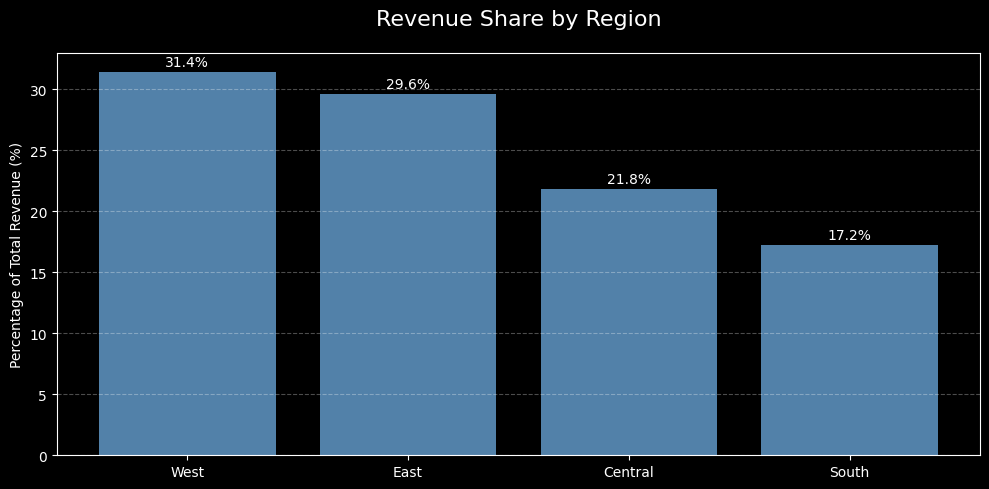

In [16]:
region_percentage = (
    sales_by_region /
    total_region_sales * 100
)

plt.style.use("dark_background")

fig_region, ax_region = plt.subplots(figsize=(10, 5))

bars_region = ax_region.bar(
    region_percentage.index,
    region_percentage,
    color=caio_blue,
    alpha=0.9
)

ax_region.set_title(
    "Revenue Share by Region",
    fontsize=16,
    pad=20
)

ax_region.set_ylabel("Percentage of Total Revenue (%)")

ax_region.grid(
    axis="y",
    linestyle="--",
    alpha=0.3
)

for bar in bars_region:
    height = bar.get_height()

    ax_region.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.5,
        f"{height:.1f}%",
        ha="center"
    )

plt.tight_layout()

plt.savefig(
    "images/Region.png",
    bbox_inches="tight",
    dpi=300
)

plt.show()



C:\Users\caiot\AppData\Local\Temp\ipykernel_16776\2142388458.py:46: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


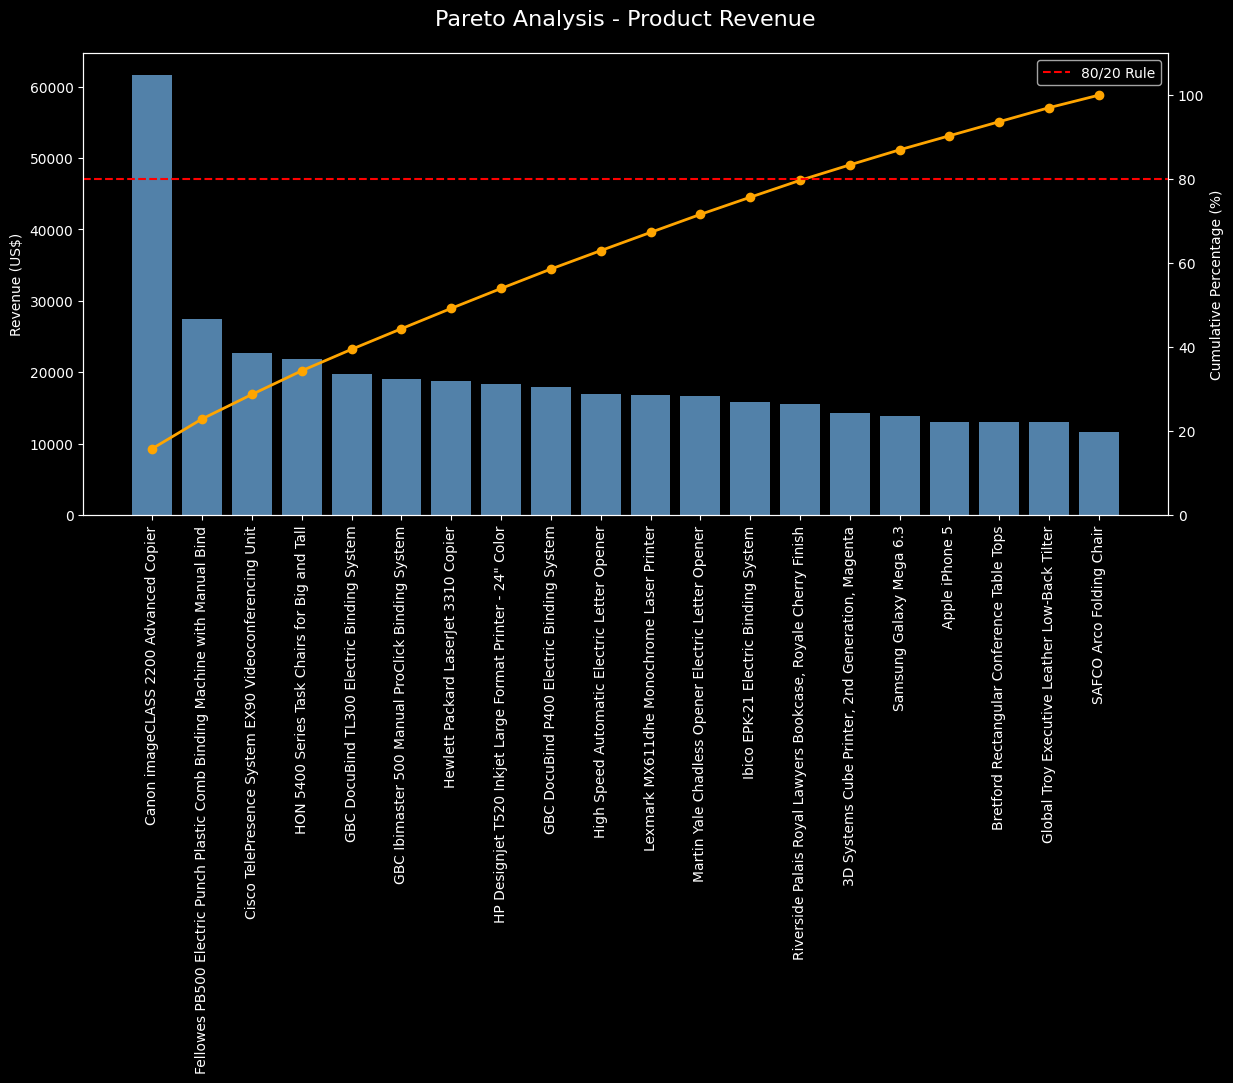

In [17]:
plt.style.use("dark_background")

fig, ax1 = plt.subplots(figsize=(14, 6))

# Revenue bars
ax1.bar(
    pareto_df["Product"],
    pareto_df["Revenue"],
    color=caio_blue,
    alpha=0.9
)

ax1.set_ylabel("Revenue (US$)")
ax1.tick_params(axis="x", rotation=90)

# Secondary axis for cumulative percentage
ax2 = ax1.twinx()

ax2.plot(
    pareto_df["Product"],
    pareto_df["Cumulative Percentage"],
    color="orange",
    marker="o",
    linewidth=2
)

ax2.set_ylabel("Cumulative Percentage (%)")
ax2.set_ylim(0, 110)

# 80/20 Rule reference line
ax2.axhline(
    y=80,
    color="red",
    linestyle="--",
    label="80/20 Rule"
)

plt.title(
    "Pareto Analysis - Product Revenue",
    fontsize=16,
    pad=20
)

ax2.legend()

plt.tight_layout()

plt.savefig(
    "images/pareto.png",
    bbox_inches="tight",
    dpi=300
)

plt.show()

